# Adding a tool - not a kids spoon

On my journey towards creating Thorsten, the overmotivated agent that wants to try out all tools the world has to offer, I am still at the very beginning. I gave him a `greet()` tool, a kid's spoon. He needs a real tool under supervision — something like `bash` or Python. How do we establish that supervision? A brief recap on tool development points toward the answer.

## Brief recap on tool development

At the end of 2022, the [ReAct pattern was coined](https://arxiv.org/abs/2210.03629) and showed up in LangChain shortly thereafter. Small `calculator()`-style tools had conquered the world; then the ChatGPT Code Interpreter brought another breakthrough in spring 2023: code execution combined with a Python Read-Eval-Print Loop (REPL). Python was offered as a universal tool to the LLM. A series of Software Engineering Benchmark (SWE) research papers ([1](https://arxiv.org/abs/2310.06770), [2](https://arxiv.org/abs/2405.15793)) tried `bash` and found it to be a mighty tool for software development tasks. Today, we see Python all over our AI-assisted coding tools.

Thorsten also needs a "real" tool — but how do we reduce the blast radius if something goes wrong?

## Sandboxing

The OpenAI ChatGPT Code Interpreter already pointed to an answer: sandboxing. Remote Code Execution (RCE) via a separate service further decouples systems.

In a professional environment, services like [E2B](https://e2b.dev/) or [fly.io (Sprites, Firecracker micro-VMs)](https://fly.io/) come to mind. This is a lab for learning and experimentation that should be self-contained where feasible. It needs its own sandbox prototype — good enough to give Thorsten a mighty tool such as `bash` or Python. The tool surface should be interchangeable with low effort.

## Design considerations

Micro virtual machines are considered state-of-the-art sandboxes with a low attack surface. I run the lab on a VM, and the lab runs in containers. Container-in-container (Docker-in-Docker, DinD) is still OK-ish for isolation because my outer shell is a VM — ignoring the fact that the VM has generous resource limits and network access. Again: it is a lab, not production grade.

When using containers, the important rule is not to grant the agent access to the container runtime — no Docker socket access. Instead, the LangGraph bridge (`graph.py`) talks to the sandbox service via a small HTTP API. Pseudocode to illustrate the contract:

- `session_start(graph_invoke_id, thread_id)` → `session_id` (start inner sandbox)
- `execute_in_session(session_id, script)` → `stdout`, `stderr`, `exit_code`
- `end_session(session_id)` (cleanup sandbox)

The `script` argument executes inside the sandbox. `execute_in_session()` treats `script` as a bash script today, but another implementation could interpret `script` differently — for example, as Python. Since the sandbox service image is based on `python:3.11-bookworm` at the time of writing, giving Thorsten Python as a tool is not far-fetched. Also, the use of an HTTP API is conceptually the same as using an external service.

The sandbox lifecycle is bound to the (sub-)graph `invoke()` duration unless the bridge calls `end_session()` earlier in a `finally` block. There is no automatic session garbage collection in this PoC.

### Runtime topology

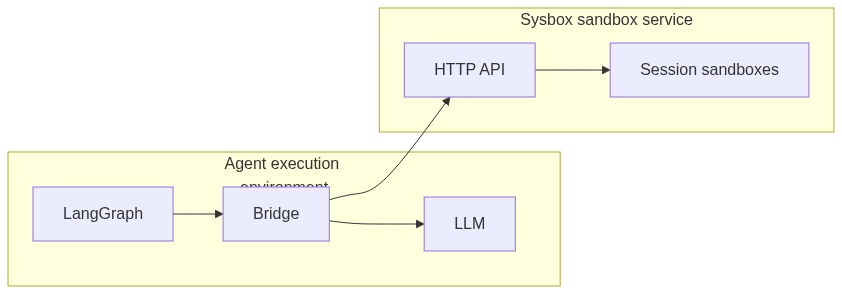

In [1]:
from IPython.display import Image, display
from langchain_core.runnables.graph_mermaid import draw_mermaid_png

# Bridge calls the sandbox service HTTP API (not individual session sandboxes).
RUNTIME_TOPOLOGY_MERMAID = """
flowchart LR
  subgraph agentEnv [Agent execution environment]
    lg[LangGraph]
    bridge[Bridge]
    llm[LLM]
    lg --> bridge --> llm
  end
  subgraph sysboxSvc [Sysbox sandbox service]
    http[HTTP API]
    sandboxes[Session sandboxes]
    http --> sandboxes
  end
  bridge --> http
"""

display(Image(draw_mermaid_png(RUNTIME_TOPOLOGY_MERMAID)))

### Out of scope for a demo

The design is good enough to demo supervised execution but it compromises on completeness. Explicitly out of scope are:

- fine-grained resource limits
- fairness across sessions
- authentication and TLS
- detailed auditing and logging
- session command filtering
- denial-of-service protection
- session garbage collection
- …

A few low-hanging fruits are in place:

- global sandbox resource limits on the `sysbox_bash` service
- basic execution timeout
- script and transport size limits
- script execution metadata returned to the bridge
- on a successful graph run, the bridge clears sessions via `end_session()`

As a lab user I can confirm: it works so far.

In this notebook we wire the subgraph and run one supervised bash call. The notebook starts as in earlier sessions. The only change is a new subgraph and node (`src/llm_nodes/tool_node_sysbox_bash/`). 

In [2]:
import os
import sys

sys.path.insert(0, "/workspace")

from src.tracing.phoenix import enable_langgraph_tracing

enable_langgraph_tracing(batch=True, verbose=False)

if not os.getenv("PHOENIX_COLLECTOR_ENDPOINT"):
    raise RuntimeError("Missing PHOENIX_COLLECTOR_ENDPOINT")
if not os.getenv("SBASH_BASE_URL"):
    raise RuntimeError("Missing SBASH_BASE_URL — is sysbox_bash healthy?")

from langchain_core.messages import HumanMessage
from langgraph.graph import END, START, StateGraph
from IPython.display import Image, display
import logging

from src.llm_nodes.global_state import GlobalState
from src.llm_nodes.pii_email.mask import demask_pii_emails
from src.llm_nodes.pii_email.nodes import get_pii_email_node
from src.llm_nodes.todo_extract.graph import (
    build_todo_extract_subgraph,
    make_todo_extract_subgraph_runner,
)
from src.llm_nodes.tool_node_sysbox_bash.graph import (
    build_tool_node_sysbox_bash_subgraph,
    make_tool_node_sysbox_bash_subgraph_runner,
)
from src.logging_setup import get_logger
from src.reducer.base_reader import BaseReducerReader
from src.reducer.reducer_session import reducer_session

# MODEL = "ollama_chat/llama3.2:3b"
# MODEL = "groq/llama-3.3-70b-versatile"
# MODEL="ollama_chat/mistral:7b"
MODEL="mistral-large-old"

pii_email = """
This is a confidential email.

Task ulf.wendel@ phpdoc dot de to buy a cup of coffee, ulf.wendel@phpdoc.de needs to plant a tree by tomorrow,
and cto@ourcompany.com needs to reach out to all employees
regarding the current coffee shortage as it is demotivating our technical staff.
Due date, if not said otherwise, is today.
"""

GRAPH_RECURSION_LIMIT = 50

logger = get_logger(__name__, "assorted/session7/tool_node_sysbox.ipynb")
logger.setLevel(logging.DEBUG)

todo_extract_graph = build_todo_extract_subgraph(MODEL)
run_todo_extract_graph = make_todo_extract_subgraph_runner(todo_extract_graph)

tool_node_sysbox_bash_graph = build_tool_node_sysbox_bash_subgraph(MODEL)
run_tool_node_sysbox_bash_graph = make_tool_node_sysbox_bash_subgraph_runner(
    tool_node_sysbox_bash_graph
)

## The ``llm_with_bash`` subgraph

In the ``llm_with_bash`` subgraph the bridge takes the role of interfacing the HTTP Interface of the sysbox service. The LLM continues to issue `tool_calls` by default, just like in the `greet()` example from the previous notebook with one refinement.

If the model fails to escape the script for the JSON `tool_calls` reply properly, which I found to happen with a 70B model when nested escaping is needed, the `llm_fence_rety` may allow a free retry not accounted against the error budget. If the exit code of the script execution is 2 and the `stderr` shows a certain pattern hinting an escaping issue, the LLM is called again without tools bound and asked to return the script as the ONLY reply as a mitigation.

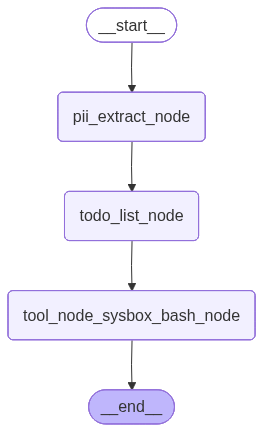

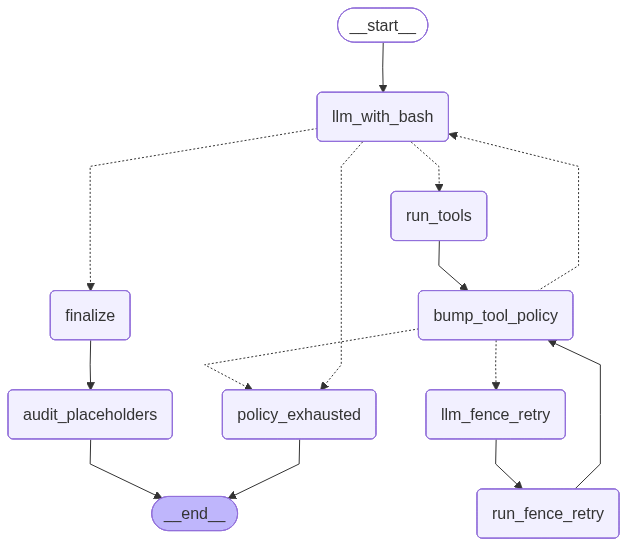

In [3]:
build_graph = StateGraph(GlobalState)

build_graph.add_node("pii_extract_node", get_pii_email_node(model=MODEL))
build_graph.add_node("todo_list_node", run_todo_extract_graph)
build_graph.add_node("tool_node_sysbox_bash_node", run_tool_node_sysbox_bash_graph)

build_graph.add_edge(START, "pii_extract_node")
build_graph.add_edge("pii_extract_node", "todo_list_node")
build_graph.add_edge("todo_list_node", "tool_node_sysbox_bash_node")
build_graph.add_edge("tool_node_sysbox_bash_node", END)

graph = build_graph.compile()

display(Image(graph.get_graph().draw_mermaid_png()))
display(Image(tool_node_sysbox_bash_graph.get_graph().draw_mermaid_png()))

In [4]:
def make_reader(get_thread_id):
    return BaseReducerReader(get_thread_id=get_thread_id)


with reducer_session("Chat-sysbox-bash", factory=make_reader) as session:
    state = session.state(GlobalState, [HumanMessage(content=pii_email)])
    reply = await session.ainvoke(
        graph,
        state,
        config={"recursion_limit": GRAPH_RECURSION_LIMIT},
    )
    state = GlobalState.model_validate(reply)

    print("TODO list:")
    for k, item in enumerate(state.todo_list.items):
        print(f"  {k + 1}): who={item.who}, what={item.what}, when={item.when}")

    print("\ntool_node_sysbox_bash result (masked final_result via bridge):")
    print(state.final_result)

    print("\nDemasked (trusted, after graph):")
    print(demask_pii_emails(state.final_result, state.pii_email))

[DEBUG] [reducer/base_reader.py:51] observing message content: 
This is a confidential email.

Task ulf.wendel@ phpdoc dot de to buy a cup of coffee, ulf.wendel@phpdoc.de needs to plant a tree by tomorrow,
and cto@ourcompany.com needs to reach out to all employees
regarding the current coffee shortage as it is demotivating our technical staff.
Due date, if not said otherwise, is today.

[DEBUG] [reducer/base_reader.py:51] observing message content: ```json
{"occurrences": [{"span": "ulf.wendel@ phpdoc dot de", "raw": "ulf.wendel@phpdoc.de"}, {"span": "ulf.wendel@phpdoc.de", "raw": "ulf.wendel@phpdoc.de"}, {"span": "cto@ourcompany.com", "raw": "cto@ourcompany.com"}]}
```
[DEBUG] [reducer/base_reader.py:51] observing message content: ```json
{"items": [{"who": "E0_df7f4741", "what": "buy a cup of coffee", "when": "today"}, {"who": "E0_df7f4741", "what": "plant a tree", "when": "tomorrow"}, {"who": "E1_df7f4741", "what": "reach out to all employees regarding the current coffee shortage", 

TODO list:
  1): who=E0_df7f4741, what=buy a cup of coffee, when=today
  2): who=E0_df7f4741, what=plant a tree, when=tomorrow
  3): who=E1_df7f4741, what=reach out to all employees regarding the current coffee shortage, when=today

tool_node_sysbox_bash result (todo_text via bridge):
# E0_df7f4741
- [ ] coffee a cup of buy (5 words) (by today)
  ```
  ( (
   ) )
 ........
 |      |]

  sandbox probe — UTC timestamp inside the container: 2026-06-17T10:39:16Z
  ```

- [ ] tree a plant (3 words) (by tomorrow)
  ```
    *
   ***
  *****
 *******
    |

  sandbox probe — Kernel version of the sandbox: 7.0.12-1-default
  ```

# E1_df7f4741
- [ ] shortage coffee current the regarding employees all to out reach (10 words) (by today)
  ```
  ( (
   ) )
 ........
 |      |]
 \______/
    ||
    ||

  sandbox probe — Number of CPU cores available in the sandbox: 10
  ```

Demasked (trusted, after graph):
# ulf.wendel@phpdoc.de
- [ ] coffee a cup of buy (5 words) (by today)
  ```
  ( (
   ) )
 ..

## Happy hacking!

At the level of these basic agent development considerations it shows that there is a lot of classical engineering included such as here, where we briefly look at the risk of an LLM causing an errenous or malicious tool call and potential retry loops as a mitigation. 

If you never tried different models, try them out:

- llama3.2:3b (2024) - no `tools_call`
- mistral:7b (2023) - prompt leakage
- llama-3.3-70b-versatile (2024) - escaping issues

How long would it take to create a tool node that is truly robust?